In [3]:
#imports and config

import os
from pathlib import Path
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from datetime import datetime

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report  # useful if you later add synthetic labels

import matplotlib.pyplot as plt
import seaborn as sns

# Optional nicer maps later (Streamlit will use these)
# import folium
# from streamlit_folium import st_folium

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# ---------- CONFIG ----------
DATA_DIR = Path("data/taxi_log")          # change if your folder is named differently
N_TAXIS = 80                              # number of taxi files to load (keep low for speed)
MIN_POINTS_PER_TAXI = 30                  # discard very short trajectories
RANDOM_SEED = 42
CONTAMINATION = 0.05                      # expected fraction of anomalies for IsolationForest

np.random.seed(RANDOM_SEED)

In [10]:
#helper functions (haversine + feature engineering)
def haversine_np(lon1, lat1, lon2, lat2):
    """Vectorized haversine distance in meters."""
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371000 * c  # Earth radius in meters


def load_taxi_file(filepath: Path) -> pd.DataFrame:
    """Load one T-Drive txt file → DataFrame with proper dtypes."""
    try:
        df = pd.read_csv(
            filepath,
            header=None,
            names=["taxi_id", "datetime", "lon", "lat"],
            dtype={"taxi_id": str, "lon": float, "lat": float},
        )
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
        df = df.dropna(subset=["datetime", "lon", "lat"])
        df = df.sort_values("datetime").reset_index(drop=True)
        return df
    except Exception as e:
        print(f"Failed to load {filepath.name}: {e}")
        return pd.DataFrame()


def compute_kinematic_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add speed, acceleration, heading change, tortuosity, etc.
    Works on a single taxi trajectory. Keeps taxi_id.
    """
    if len(df) < 3:
        return df

    df = df.copy()
    taxi_id = df["taxi_id"].iloc[0]          # preserve the ID

    df["dt_sec"] = df["datetime"].diff().dt.total_seconds()

    # Distance between consecutive points (meters)
    df["dist_m"] = haversine_np(
        df["lon"].shift(), df["lat"].shift(),
        df["lon"], df["lat"]
    )

    # Speed (m/s) and km/h
    df["speed_ms"] = df["dist_m"] / df["dt_sec"]
    df["speed_kmh"] = df["speed_ms"] * 3.6

    # Acceleration (m/s²)
    df["accel_ms2"] = df["speed_ms"].diff() / df["dt_sec"]

    # Heading (degrees) and change in heading
    dy = df["lat"].diff()
    dx = df["lon"].diff()
    df["heading_deg"] = np.degrees(np.arctan2(dy, dx))
    df["heading_change"] = df["heading_deg"].diff().abs()
    # wrap to [0, 180]
    df["heading_change"] = df["heading_change"].apply(
        lambda x: min(x, 360 - x) if pd.notna(x) else np.nan
    )

    # Tortuosity over the whole track
    total_path = df["dist_m"].sum()
    start_end = haversine_np(
        df["lon"].iloc[0], df["lat"].iloc[0],
        df["lon"].iloc[-1], df["lat"].iloc[-1]
    )
    df["tortuosity"] = total_path / start_end if start_end > 1 else np.nan

    # Clean impossible values
    df.loc[df["dt_sec"] <= 0, ["speed_ms", "speed_kmh", "accel_ms2"]] = np.nan
    df.loc[df["speed_kmh"] > 150, "speed_kmh"] = np.nan   # taxi speed sanity
    df.loc[df["accel_ms2"].abs() > 10, "accel_ms2"] = np.nan

    df["taxi_id"] = taxi_id                  # re-attach just in case
    return df

In [11]:
#load sample of taxis
# List all available taxi files
all_files = sorted(DATA_DIR.glob("*.txt"))
print(f"Found {len(all_files)} taxi files")

# Randomly sample N_TAXIS files
np.random.seed(RANDOM_SEED)
selected_files = np.random.choice(all_files, size=min(N_TAXIS, len(all_files)), replace=False)

dfs = []
for f in selected_files:
    df = load_taxi_file(f)
    if len(df) >= MIN_POINTS_PER_TAXI:
        dfs.append(df)

raw = pd.concat(dfs, ignore_index=True)
print(f"Loaded {raw['taxi_id'].nunique()} taxis, {len(raw):,} points")
print(raw.head())
print("\nDate range:", raw["datetime"].min(), "→", raw["datetime"].max())

Found 10357 taxi files
Loaded 77 taxis, 106,880 points
  taxi_id            datetime        lon       lat
0    7113 2008-02-02 13:39:06  116.31600  39.76258
1    7113 2008-02-02 13:44:06  116.31677  39.74200
2    7113 2008-02-02 13:49:06  116.31535  39.72229
3    7113 2008-02-02 13:54:06  116.30672  39.69833
4    7113 2008-02-02 13:56:54  116.29972  39.68704

Date range: 2008-02-02 13:31:38 → 2008-02-08 17:39:12


In [12]:
#feature engineering on every trajectory

# Apply kinematic features per taxi – robust way that never loses taxi_id
featured_list = []
for taxi_id, group in raw.groupby("taxi_id"):
    feat = compute_kinematic_features(group)
    featured_list.append(feat)

featured = pd.concat(featured_list, ignore_index=True)

print("Featured data shape:", featured.shape)
print(featured[["taxi_id", "datetime", "speed_kmh", "accel_ms2", "heading_change"]].describe())
print("\nColumns present:", featured.columns.tolist())

Featured data shape: (106880, 12)
                         datetime     speed_kmh     accel_ms2  heading_change
count                      106880  99071.000000  94758.000000   106726.000000
mean   2008-02-05 07:43:16.978967     13.951319     -0.008157       53.910625
min           2008-02-02 13:31:38      0.000000     -9.770939        0.000000
25%           2008-02-03 20:07:05      0.040866     -0.006145        4.077799
50%           2008-02-05 00:43:38      8.693237      0.000000       34.256156
75%    2008-02-06 17:25:58.500000     22.229755      0.007070       90.000000
max           2008-02-08 17:39:12    149.353887      9.668778      180.000000
std                           NaN     16.876075      0.424733       55.815331

Columns present: ['taxi_id', 'datetime', 'lon', 'lat', 'dt_sec', 'dist_m', 'speed_ms', 'speed_kmh', 'accel_ms2', 'heading_deg', 'heading_change', 'tortuosity']


In [13]:
#aggregate features per trajectory

def trajectory_summary(g: pd.DataFrame) -> pd.Series:
    """Create one feature vector per taxi trajectory."""
    return pd.Series({
        "n_points": len(g),
        "duration_min": (g["datetime"].max() - g["datetime"].min()).total_seconds() / 60,
        "total_dist_km": g["dist_m"].sum() / 1000,
        "mean_speed_kmh": g["speed_kmh"].mean(),
        "std_speed_kmh": g["speed_kmh"].std(),
        "max_speed_kmh": g["speed_kmh"].max(),
        "mean_accel": g["accel_ms2"].mean(),
        "std_accel": g["accel_ms2"].std(),
        "max_abs_accel": g["accel_ms2"].abs().max(),
        "mean_heading_change": g["heading_change"].mean(),
        "std_heading_change": g["heading_change"].std(),
        "max_heading_change": g["heading_change"].max(),
        "tortuosity": g["tortuosity"].iloc[0] if "tortuosity" in g else np.nan,
        "pct_high_speed": (g["speed_kmh"] > 60).mean(),   # fraction of points > 60 km/h
    })

traj_features = (
    featured.groupby("taxi_id")
            .apply(trajectory_summary)
            .dropna()
)

print(f"Trajectory-level feature matrix: {traj_features.shape}")
traj_features.head()

Trajectory-level feature matrix: (76, 14)


,n_points,duration_min,total_dist_km,mean_speed_kmh,std_speed_kmh,max_speed_kmh,mean_accel,std_accel,max_abs_accel,mean_heading_change,std_heading_change,max_heading_change,tortuosity,pct_high_speed
taxi_id,,,,,,,,,,,,,,
10029,1719.0,8879.750000,1254.327326,8.588909,15.222892,98.718194,0.000455,0.023774,0.839000,86.659278,57.752755,180.000000,57.010936,0.015125
10032,709.0,8868.283333,673.802295,17.994742,16.056231,76.057330,0.064184,0.558409,5.902462,58.441381,56.027667,179.851601,349.141499,0.014104
10287,3308.0,8882.883333,926.762692,4.856317,12.316525,86.209867,0.002556,0.095244,2.469831,17.160008,40.519681,180.000000,160.080625,0.008162
1081,2365.0,8861.933333,3993.328932,17.303921,14.415868,95.060025,-0.030922,0.475821,8.065682,54.315937,51.558961,180.000000,91.194547,0.020296
1114,1573.0,8880.633333,996.640457,11.459903,17.648940,103.337121,0.011327,0.240124,5.997610,29.367637,45.535984,180.000000,10.722241,0.030515


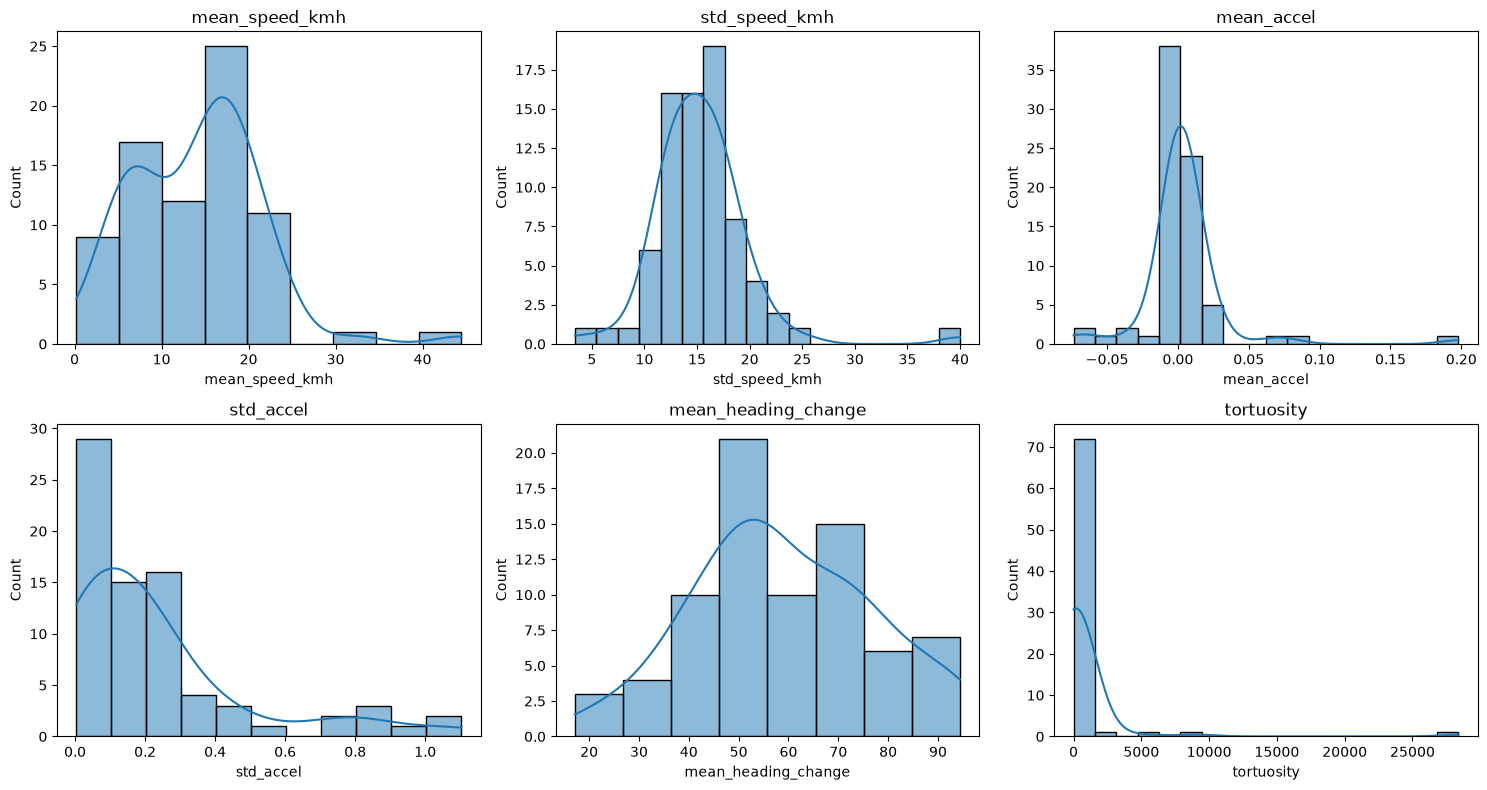

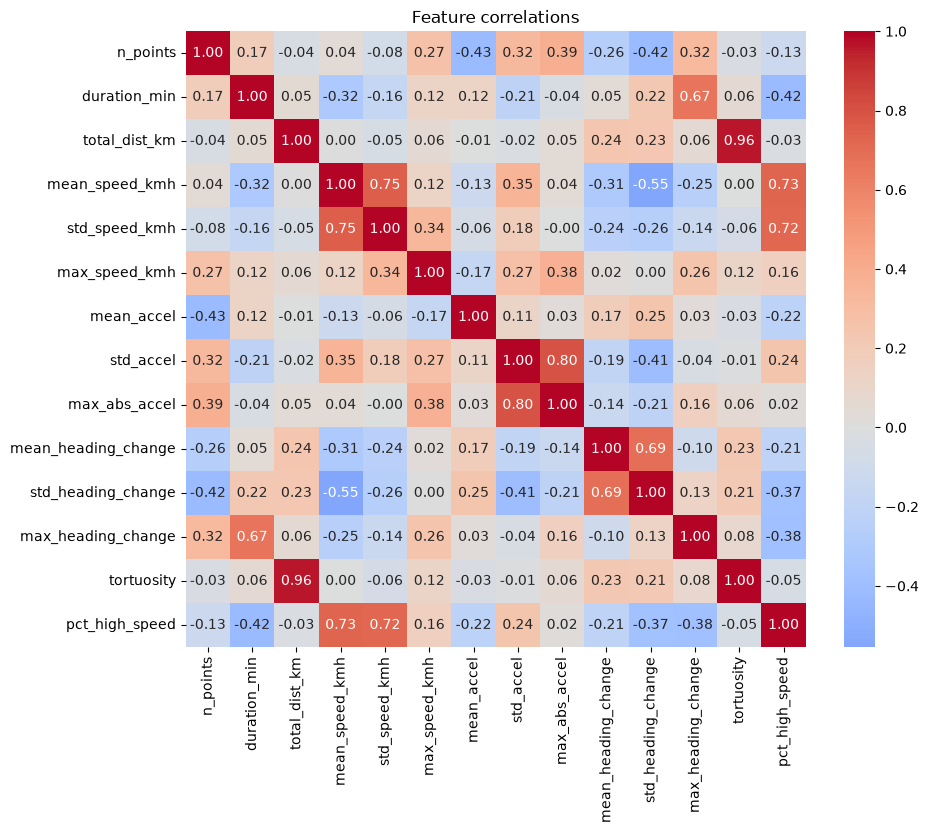

In [ ]:
#exploratory analysis

# Distributions of key kinematic features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols = ["mean_speed_kmh", "std_speed_kmh", "mean_accel", "std_accel",
        "mean_heading_change", "tortuosity"]

for ax, col in zip(axes.ravel(), cols):
    sns.histplot(traj_features[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(traj_features.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlations")
plt.show()

In [15]:
# Select features for the model (drop pure size metrics if you want)
feature_cols = [
    "mean_speed_kmh", "std_speed_kmh", "max_speed_kmh",
    "mean_accel", "std_accel", "max_abs_accel",
    "mean_heading_change", "std_heading_change", "max_heading_change",
    "tortuosity", "pct_high_speed"
]

X = traj_features[feature_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan).dropna()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train
iso = IsolationForest(
    n_estimators=200,
    contamination=CONTAMINATION,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
iso.fit(X_scaled)

# Scores & labels (-1 = anomaly, 1 = normal)
traj_features.loc[X.index, "anomaly_score"] = -iso.decision_function(X_scaled)  # higher = more anomalous
traj_features.loc[X.index, "is_anomaly"] = iso.predict(X_scaled) == -1

print("Anomaly rate:", traj_features["is_anomaly"].mean())
print("\nTop 10 most anomalous taxis:")
print(traj_features.sort_values("anomaly_score", ascending=False).head(10)[
    ["n_points", "mean_speed_kmh", "std_speed_kmh", "mean_heading_change", "tortuosity", "anomaly_score"]
])

Anomaly rate: 0.05263157894736842

Top 10 most anomalous taxis:
         n_points  mean_speed_kmh  std_speed_kmh  mean_heading_change    tortuosity  anomaly_score
taxi_id                                                                                           
7864        246.0       44.461340      25.061401            38.080360      1.980623       0.173694
2625        254.0       16.883548      13.727783            77.658298     14.529739       0.060928
1597        206.0       32.259859      39.986582            56.135301      1.718854       0.051805
9698        808.0       14.986876      14.088005            93.732136  28392.008397       0.028474
7806       4824.0       23.467154      17.883263            40.721782     57.629072      -0.009491
2488        269.0        6.128237      11.113438            22.852657    165.358785      -0.018798
3026       1070.0       16.183353      20.821764            52.349886    956.641567      -0.019158
1741       8795.0       24.106563      16.432

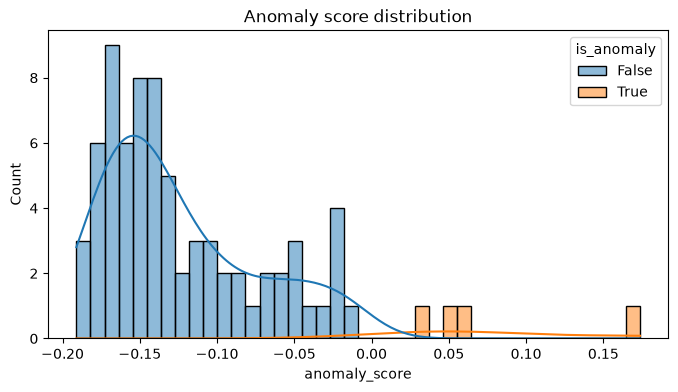

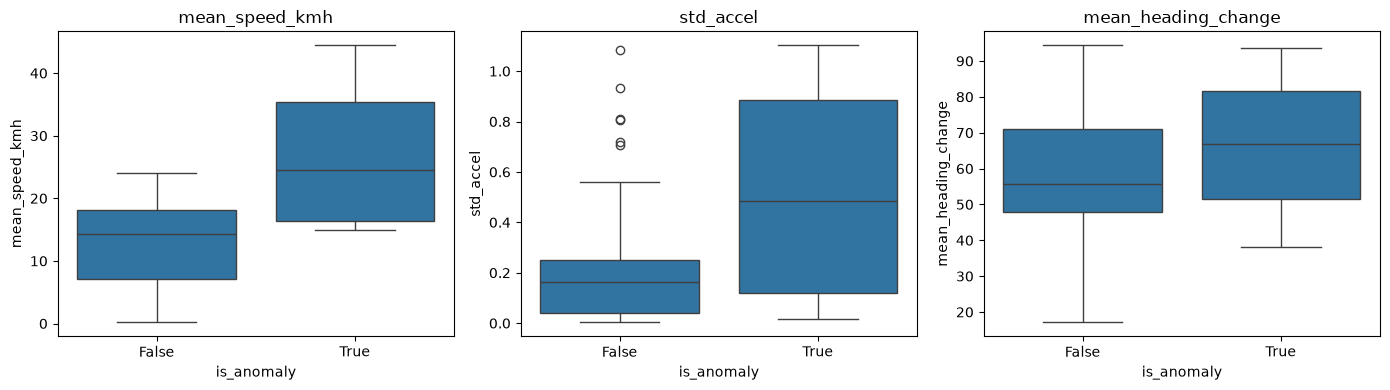

In [16]:
# Score distribution
plt.figure(figsize=(8, 4))
sns.histplot(data=traj_features, x="anomaly_score", hue="is_anomaly", bins=40, kde=True)
plt.title("Anomaly score distribution")
plt.show()

# Boxplots of key features by anomaly flag
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["mean_speed_kmh", "std_accel", "mean_heading_change"]):
    sns.boxplot(data=traj_features, x="is_anomaly", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [18]:
# Save the feature matrix + model artifacts
traj_features.to_csv("data/trajectory_features.csv", index=True)
print("Saved trajectory_features.csv")

import joblib
joblib.dump(iso, "models/isolation_forest.joblib")
joblib.dump(scaler, "models/scaler.joblib")
joblib.dump(feature_cols, "models/feature_cols.joblib")
print("Saved model + scaler + feature list")

Saved trajectory_features.csv
Saved model + scaler + feature list


In [23]:
# -------------------------------------------------
# Save point-level data for map visualization
# -------------------------------------------------
from pathlib import Path
Path("data").mkdir(exist_ok=True)

# Mark which trajectories are anomalous
anom_ids = set(traj_features[traj_features["is_anomaly"]].index.astype(str))

# Create a flag on the point-level data
featured["is_anomaly"] = featured["taxi_id"].astype(str).isin(anom_ids)

# Keep ALL anomalous trajectories + a random sample of normal ones
normal_ids = list(set(featured["taxi_id"].astype(str)) - anom_ids)
np.random.seed(42)
sample_normal = np.random.choice(normal_ids, size=min(40, len(normal_ids)), replace=False)

keep_ids = list(anom_ids) + list(sample_normal)

map_df = featured[featured["taxi_id"].astype(str).isin(keep_ids)].copy()

def downsample(df, max_points=400):
    if len(df) <= max_points:
        return df
    step = max(1, len(df) // max_points)
    return df.iloc[::step]

# Explicit loop – works on every pandas version
parts = []
for taxi_id, group in map_df.groupby("taxi_id"):
    sampled = downsample(group)
    # Guarantee the column is present
    if "taxi_id" not in sampled.columns:
        sampled = sampled.copy()
        sampled["taxi_id"] = taxi_id
    parts.append(sampled)

map_df = pd.concat(parts, ignore_index=True)

print(f"Saving {map_df['taxi_id'].nunique()} trajectories ({len(map_df):,} points) for the map")
map_df.to_parquet("data/map_trajectories.parquet", index=False)
print("Saved → data/map_trajectories.parquet")

Saving 44 trajectories (18,356 points) for the map
Saved → data/map_trajectories.parquet
